<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-WK8-Group-Assignment/blob/main/EMSC2010_Group_Project_WK8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Cloudy with a chance of stats

Project week: 8

Project title: When will the steps of the Sydney Opera House be submerged from rising ocean levels due to Greenland ice melt?

Datasets used (name and source):                        
Ice-melting rate from Copernicus, implemented by the European Commission (https://climate.copernicus.eu/climate-indicators/ice-sheets)               
Indication of how much water is needed to submerge the Opera House steps from Coastal Risk Australia (https://www.coastalrisk.com.au/viewer)    
Conversion of ice melt amount to sea-level rise from Antarctica Glaciers (https://www.antarcticglaciers.org/glaciers-and-climate/estimating-glacier-contribution-to-sea-level-rise/)

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Deadline |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Leo | Cathy | Yes| 1/05|
| Data steward | Cathy | Elena | Yes| 1/05|
| Analysis / modelling | Elena | Sutton | Yes| 3/05|
| Visualisation / interpretation | Sutton | Sameer | Yes | 4/05|
| Narrative | Sameer | Kimi | Yes| 6/05|
| Quality Control / Reproducibility  | Kimi | Leo | Yes| 7/05|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Project Overview**

This project aims to answer a critical, yet visually impactful, question: When will the iconic steps of the Sydney Opera House be submerged due to global sea-level rise, specifically focusing on the contribution from Greenland ice melt? The Sydney Opera House, situated at sea level, provides a relatable and significant landmark to illustrate the long-term consequences of climate change. We identified that a sea-level rise of approximately 3000mm would be required to submerge its lower steps, establishing a clear threshold for our analysis.

Our focus on the Greenland Ice Sheet is strategic. It represents one of the largest contributors to global sea-level rise, and extensive, high-quality observational data are readily available from initiatives like the Ice Sheet Mass Balance Inter-comparison Exercise (IMBIE). While other ice sheets and thermal expansion also contribute to sea-level rise, isolating Greenland allows for a focused and robust modeling exercise based on a well-documented dataset. The dataset provides cumulative mass balance data in gigatonnes (Gt), which can be directly converted into an equivalent sea-level rise.

The initial phase involved understanding the nature of the ice melt data and how best to model its progression over extended periods. We anticipated a non-linear trend, given the complex dynamics of ice melt, leading us to consider advanced regression techniques. The primary challenge was to project historical and current melt rates far into the future, providing a probabilistic estimate of when our defined threshold would be crossed. This project serves as a compelling case study of applying Bayesian statistical modeling to real-world climate data for long-term predictions.


---



**Data Import**

Greenland Ice Sheet melt data were collected by the Ice Sheet Mass Balance Inter-comparison Exercise (IMBIE). The Greenland Ice Sheet was selected because long-term observational data are readily available, and because it contains enough ice that, if fully melted, it could significantly contribute to global sea-level rise. As the dataset spans from 1972 to the end of 2025, it provides sufficient temporal coverage to sample predictive posterior distributions of future melt progression. The variable of interest is the cumulative mass balance of the ice sheet, measured in gigatonnes (Gt). No modifications were made to the dataset.

Data can be found here: https://climate.copernicus.eu/climate-indicators/ice-sheets

In [1]:
import pandas as pd #used to read and clean data
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# This cell defines variables for the Excel spreadsheet and sheet names.
# These variables will be used later to import data from the specified sheets.
spreadsheet_name = 'Greenland_Data-1.xlsx' # Name of the Excel file containing the ice melt data.
Sheet1 = 'Data' # Name of the worksheet containing the data.

In [3]:
Greenland_df = pd.read_excel(
    spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Sheet1, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)
Greenland_df.head() # Display the first few rows of the created DataFrame to verify data loading and structure.

,Year,Mass balance (Gt/yr),Mass balance uncertainty (Gt/yr),Cumulative mass balance (Gt),Cumulative mass balance uncertainty (Gt)
0,1971.500000,65.9465,68.5751,5.495542,19.795927
1,1971.583333,65.9465,68.5751,10.991083,27.995668
2,1971.666667,65.9465,68.5751,16.486625,34.287551
3,1971.750000,65.9465,68.5751,21.982167,39.591853
4,1971.833333,65.9465,68.5751,27.477708,44.265038


**Data Analysis/Modelling**

Our approach began by converting cumulative ice mass balance data from Greenland into equivalent sea level rise, using a factor of 361.8 Gt per 1mm. This sea_level_tot variable was then centered to represent current sea level, making future projections clearer. We employed the bambi library to build a Bayesian regression model, specifically a second-order polynomial (y ~ {x**2}), to capture non-linear trends in sea level rise. Model diagnostics, including prior and trace plots, confirmed the stability and convergence of our MCMC samples. Subsequently, we projected sea level changes up to the year 6500, calculating the posterior mean and 95% Highest Density Interval (HDI) to quantify both prediction and associated uncertainty. A key note from the team (Elena) confirmed the deliberate choice of a quadratic model to best fit the anticipated non-linear ice melt trend.

1mm of sea level rise is equal to 361.8 Gt of ice melting.
Sea level rise was calculated using this website: https://www.antarcticglaciers.org/glaciers-and-climate/estimating-glacier-contribution-to-sea-level-rise/

From this code below, we know that sea levels have risen around 17.45mm since 1971 due to Greenland melting.

In [4]:
year=Greenland_df['Year']   #read in dates from spreadsheet
mass=Greenland_df['Mass balance (Gt/yr)']   #read in yearly ice melt data from spreadsheet
sea_level_rise=mass/-361.8                  #convert to a sea level rise
cumul_mass=Greenland_df['Cumulative mass balance (Gt)']   #read in cumulative ice melt data from spreadsheet
sea_level_tot=cumul_mass/-361.8                           #convert to a sea level rise
sea_level_tot=sea_level_tot-sea_level_tot.iloc[-1]        #centre it so 0mm rise is 'today' and subsequent rise from there is easily calculated
print(sea_level_tot)

0     -17.461464
1     -17.476654
2     -17.491843
3     -17.507033
4     -17.522222
         ...    
649    -0.182602
650    -0.136952
651    -0.091301
652    -0.045651
653     0.000000
Name: Cumulative mass balance (Gt), Length: 654, dtype: float64


In [5]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 13.0 MB/s eta 0:00:00


In [6]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models

In [7]:
data = pd.DataFrame({"x": year, "y": sea_level_tot}) #put the data into a dataframe with variable names "x" and "y".
model = bmb.Model("y ~ {x**2}", data) #setup the second-order polynomial model
idata = model.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

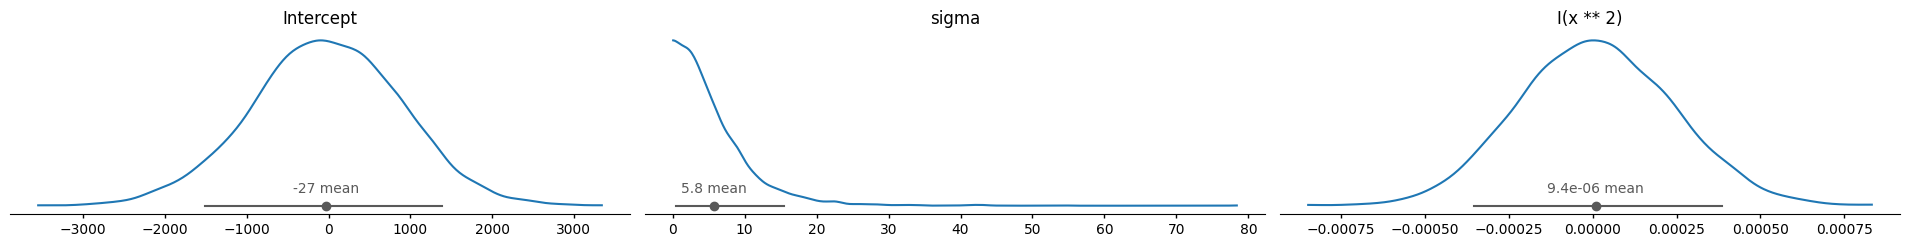

In [8]:
## Checking the priors look good & make sense
model.plot_priors()
plt.tight_layout()
plt.show()

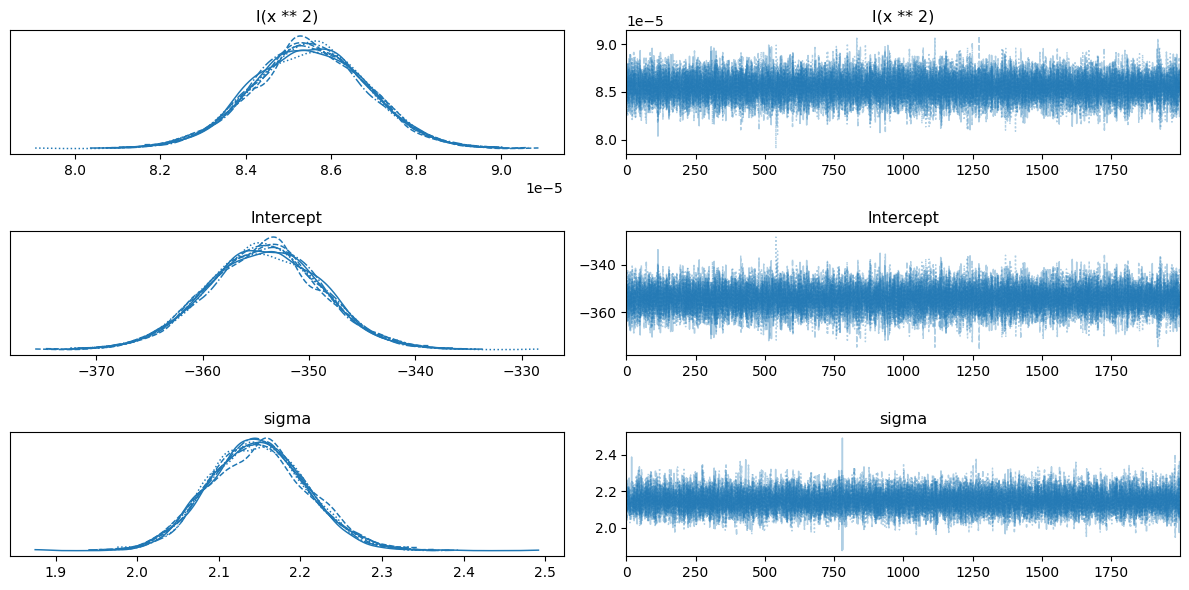

In [9]:
az.plot_trace(idata);
plt.tight_layout() #this spaces the plots out so that they don't overlap

In [10]:
# Predict across a range of x values
x_range = np.linspace(1971, 6500, 5000) # Predict across a range of x values from the year 1971 to 6500
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the gravel size
y_pps_draws = idata.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution# Compute posterior mean and HDI at each x point
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)

/tmp/ipykernel_1141/3531260183.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean = az.hdi(idata.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
/tmp/ipykernel_1141/3531260183.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)


**Data Visualisation/Interpretation**

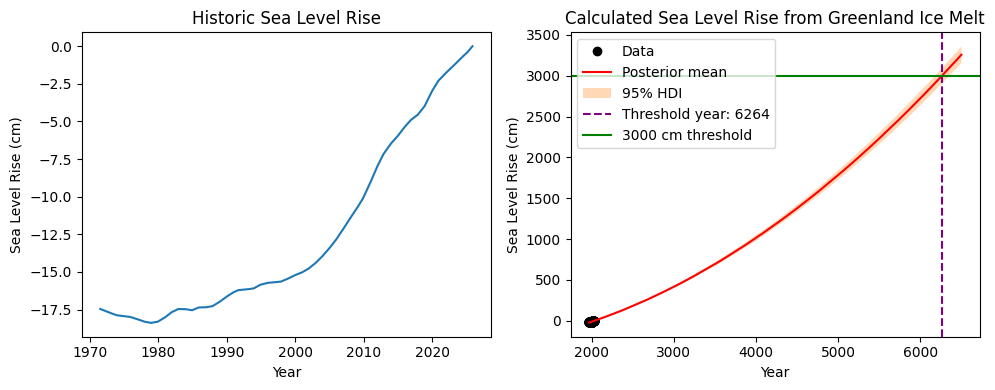

In [11]:
#Plot the collected data and also the calculated posterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #Create 2 subplots
ax1.plot(year, sea_level_tot) #On the first subplot, plot just the sourced sea level data
ax2.plot(year, sea_level_tot, 'ok', label="Data") #On the second subplot, plot the recorded sea level data
ax2.plot(x_range, posterior_mean, 'r', label="Posterior mean") #Add the posterior mean calculated sea level o the second subplot
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
) #Shade the highest density interval of the posterior mean on the second subplot

# Calculate the years when the posterior mean sea level rise exceeds 3000 cm
years_exceeding_3000 = x_range[posterior_mean >= 3000]

# Check if any years exceed the threshold before trying to access the first element
if len(years_exceeding_3000) > 0:
    threshold_year = years_exceeding_3000[0] # Get the first year when sea level exceeds 3000cm
    ax2.axvline(threshold_year, linestyle="--", color='purple', label=f"Threshold year: {threshold_year:.0f}")
else:
    print("The sea level does not exceed 3000cm within the predicted range.")
    threshold_year = None

ax2.axhline(3000, linestyle="-", color='green', label="3000 cm threshold") # Add a horizontal line for the 3000cm mark

ax1.set_title('Historic Sea Level Rise')
ax2.set_title('Calculated Sea Level Rise from Greenland Ice Melt')
ax1.set_xlabel('Year') #label x-axis for ax1
ax2.set_xlabel('Year') #label x-axis for ax2
ax1.set_ylabel('Sea Level Rise (cm)') #label y-axis for ax1
ax2.set_ylabel('Sea Level Rise (cm)') #label y-axis for ax2
plt.legend()
plt.tight_layout()
plt.show() #Show the plot

In [12]:
#Find the HDI range at the threshold year
index_6264 = np.argmin(np.abs(x_range - 6264))
year_at_idx = x_range[index_6264]
hdi_at_6264 = hdi_pps[index_6264]

print(f"For the year closest to {year_at_idx:.0f} (index {index_6264}):")
print(f"The 95% HDI range for sea level rise is from {hdi_at_6264[0]:.2f} cm to {hdi_at_6264[1]:.2f} cm")

For the year closest to 6264 (index 4739):
The 95% HDI range for sea level rise is from 2904.01 cm to 3091.77 cm


In [13]:
#Calculate the percent of the HDI at the threhold year that is over the threshold
c = 3097.33-2907.21
p = 97.33/c
print(p)

0.511939827477383


Data Interpretation & Visualization

The aim of our investigation was to calculate when the Sydney opera House steps would be submerged from rising sea levels due to the melting of the Greenland ice sheet. To submerge the steps sea level would have to rise an additional 3000cm from todays sea level which we have termed our threshold.

The above subplots show firstly, the recorded historic sea level rise upto present time and secondly the historical data and the posterior calculated mean sea level rise due to ice melt from Greenland. Superimposed upon the second subplot is also the highest density interval of the posterior and the lines marking the threshold. The 3000cm threshold is shown on the plot to be reached in the year 6264, with just over half (0.51) of the HDI at this point (2907.21 - 3097.33) also above the threshold.

It is important to note that this investigation is very arbitrary in that we only consider Greenland ice melt and not all the frozen water reservoirs across the world that will impact global sea level rise due to changing climate. Greenland only occupies around 10% of global land ice If all additions to the volume of the global ocean were accounted for the threshold would be reached earlier than 6264.

# **Reflections**

**Leo**

This week I had the role of GitHub repository. This role did not really offer the potential challenges and learning experiences resulting from the unique task as it is a pretty standard role that doesn't change with the topic. I created the GitHub repositery, initialised and shared the Colab, prepared sections for all tasks to be completed so that the final notebook would flown smoothly. I also regularly checked additions to the Colab and committed them to GitHub. I drew upon the help of previous people in the role as I sent through a couple wrong links/created the wrong file name/type a couple times but thankfully I had a good group to pull me up on it. I learnt a couple things about tidying up the GitHub repository, such as commit messages and deleting files.

**Cathy**

This week my role consisted of finding and loading data related to the melt of the Greenland Ice Sheet. Due to satellite observational data being widely available from the partnership of NASA and the ESA through the Ice Sheet Mass Balance Inter-comparison Exercise, I was able to find data that recorded the changes in mass balance and cumulative mass balance of the ice sheet over time, as well as its uncertainties. There was no clean up needed to be done as there was data for each year and no outliers were observed after a quick plot of the Greenland Ice Sheet cumulative mass balance over time. I was able to then load up the data onto the colab project and define the sheet that contained the data Elena were going to analyse, as I created another worksheet in the excel file describing the figure metadata I could find. The first row of the sheet was skipped to make the analysis easier.


**Elena**

This week my role was to analyse and model the data. This involved following in the footsteps of the practical this week, using Bambi to create a Bayesian model for the melting of Greenland's ice. I had to take it a little further than what we looked at in class, because the data we had did not fit a linear model as well as it fit a quadratic. This involved research and a bit of collaboration with Sutton during the visualisation stage to ensure the model was created correctly. With a little bit of trial and error, it worked! Another step I had to take in this process to make it suit our question better was modifying the zero-point of our data. The raw data we got from our source chose to start their zero-point from which the melt amount was measured as the first year the data was collected. However, we determined that the sea-levels needed to rise an extra 300cm from *today* in order to flood the Sydney Opera House steps. This meant readjusting the data so the zero-point was the final data point collected.

**Sutton**

This week, I was responsible for data visualisation and interpretation. This involved me using matplotlib to create plots to show both the data set we were working with (recorded sea level rise over time) and our calculated posterior mean for a future scenario of how sea level will change from Greenland ice melt as well as adding markers for identifying the threshold we were looking for (3000cm rise to cover Sydney Opera House steps). Once I had visualised the data I then had to interpret it and explain what our findings were. Through completing this I became more confident in my coding ability to create plots with matplotlib that will be extremely useful in the future.

**Sameer**

This week, my primary role was to serve as the 'Narrative' lead for our group project. My core contribution involved weaving together the distinct phases of our project—from the initial overview and data acquisition to the complex modeling and final interpretation—into a cohesive and understandable story. The goal was to ensure that anyone, even someone unfamiliar with the project's specifics, could grasp our methodology, findings, and the implications of our work.

**Kimi**

My role as quality control this week meant that i had to fix some errors that occured within the notebook, look over grammar and spelling, and ensure that the repository had the correct files. Firstly, i had to change the spreadsheet name in the 'defining variables for excel' cell, as we had created another spreadsheet that followed FAIR data principles and had a different name. There were also some other minor coding errors, this included the second last cell where there were some issues with defining variables and not using them within the actual analysis, however, such issues were easy to fix as it only required changing some names. As for the spelling and grammar, not much needed to be fixed. Additionally, toward the end while checking the repository, i realised that we cannot access the colab notebook due to the progress bar being present, so i also wrote some code to fix that issue. The work done by my group mates made this role quite easy. Overall, a valuable learning lesson, hopefully as i take on my next role i am able to learn from this week and ensure that i check over my work thoroughly.